# Ground Condition Predictor

**Pipeline overview:**
1. **Step detection** — Savitzky-Golay smoothed heel pressure peak-finding
2. **Feature extraction** — per-step biomechanical features (impact magnitude, loading rate, midstance balance, per-sensor pressure stats)
3. **Training** — Random Forest trained on labelled grass / brick / concrete data
4. **Prediction** — classify each step in any new CSV

> Pass any new CSV in **Section 2**. The rest runs automatically.


## 0. Imports & Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import skew, kurtosis as scipy_kurtosis
import joblib
import warnings; warnings.filterwarnings('ignore')

# ── Sensor groups (Stappone insole layout) ────────────────────────────
HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05',
                    'pressure_06', 'pressure_09']
ALL_SENSORS      = [f'pressure_{i:02d}' for i in range(1, 13)]
IMU_COLS         = ['accel_x', 'accel_y', 'accel_z',
                    'gyro_x', 'gyro_y', 'gyro_z',
                    'magn_x', 'magn_y', 'magn_z']

# ── Algorithm parameters ──────────────────────────────────────────────
SMOOTH_WIN=11; SMOOTH_POLY=2; PEAK_DIST=50; PEAK_PROM=200; PEAK_HT=500
SAMPLING_HZ=62.5; HILL_WIN=10; MIN_DP=5

SURFACE_COLORS = {'grass':'#4CAF50','brick':'#E64A19','concrete':'#607D8B',
                  'Grass':'#4CAF50','Brick':'#E64A19','Concrete':'#607D8B','unknown':'#9E9E9E'}
print('Ready.')

Ready.


## 1. Core Functions

### 1a. Preprocessing

In [4]:
def preprocess(df):
    """Sort by timestamp, add time_sec column."""
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['time_sec']  = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    return df


### 1b. Step Detection

In [5]:
def find_step_windows(df, sensors=None):
    """Return stance-peak indices from the smoothed summed heel signal."""
    if sensors is None: sensors = HEEL_SENSORS
    y = sum(pd.to_numeric(df[s], errors='coerce').fillna(0).to_numpy(float)
            for s in sensors if s in df.columns)
    n = len(y)
    sw = min(SMOOTH_WIN, n - (0 if n % 2 == 1 else 1))
    if sw % 2 == 0: sw -= 1
    if sw <= SMOOTH_POLY: sw = SMOOTH_POLY+3+(1 if (SMOOTH_POLY+3)%2==0 else 0)
    ys = savgol_filter(y, sw, min(SMOOTH_POLY, sw-1))
    peaks, _ = find_peaks(ys, distance=PEAK_DIST,
                           prominence=PEAK_PROM, height=PEAK_HT)
    return peaks


### 1c. Per-Step Feature Extraction

For every detected step window we compute:
- **`impact_mag`** — peak `|accel_y|` at heel strike (hardness proxy)
- **`loading_rate`** — heel pressure rise ÷ time (stiffness proxy)
- **`midstance_diff`** — heel/forefoot balance at midstance
- **`heel_pmax`, `fore_pmax`, `total_pmax`** — peak pressures
- **`heel_mean`, `fore_mean`, `heel_fore_ratio`** — mean pressure ratios
- **`stance_duration`** — step window length in seconds
- **`pressure_XX_mean`** — mean of each individual sensor in the window


In [6]:
def extract_step_features(df, surface_label='unknown', foot_label='unknown'):
    df = df.copy().reset_index(drop=True)
    t         = df['time_sec'].values
    heel_sig  = df[HEEL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    fore_sig  = df[FOREFOOT_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    heel_norm = heel_sig / len(HEEL_SENSORS)
    fore_norm = fore_sig / len(FOREFOOT_SENSORS)
    accel_y   = pd.to_numeric(df['accel_y'], errors='coerce').fillna(0).values
    total_p   = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    peaks = find_step_windows(df)
    if len(peaks) < 2: return pd.DataFrame()

    rows = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        wh=heel_sig[p1:p2]; wf=fore_sig[p1:p2]
        whn=heel_norm[p1:p2]; wfn=fore_norm[p1:p2]
        way=accel_y[p1:p2]; wtp=total_p[p1:p2]; wt=t[p1:p2]

        c_loc = int(np.argmin(wh))
        diff  = np.abs(whn[c_loc:] - wfn[c_loc:])
        m_loc = c_loc + int(np.argmin(diff))
        hw    = min(int(0.15 * SAMPLING_HZ), len(way) - 1)
        impact= float(np.max(np.abs(way[max(0,c_loc-hw):c_loc+hw+1])))

        lr_vals = []
        for s in HEEL_SENSORS:
            if s not in df.columns: continue
            sy  = pd.to_numeric(df[s], errors='coerce').fillna(0).values[p1:p2]
            hlo = int(np.argmin(sy))
            seg = sy[hlo:min(hlo+HILL_WIN, len(sy))]
            if len(seg) < 2: continue
            lp,_ = find_peaks(seg, prominence=1)
            hhi  = lp[0] if len(lp) else int(np.argmax(seg[1:])) + 1
            dt   = wt[hlo+hhi]-wt[hlo] if hlo+hhi < len(wt) else 0
            dp   = seg[hhi] - seg[0]
            if dt > 0 and dp >= MIN_DP: lr_vals.append(dp / dt)
        loading_rate = float(np.mean(lr_vals)) if lr_vals else 0.0

        per_s = {f'{s}_mean': float(pd.to_numeric(df[s], errors='coerce').fillna(0).values[p1:p2].mean())
                 if s in df.columns else 0.0 for s in ALL_SENSORS}
        hm = float(wh.mean()); fm = float(wf.mean())
        rows.append({
            'surface': surface_label, 'foot': foot_label, 'step_id': i+1,
            'contact_time_sec': float(t[p1+c_loc]),
            'stance_duration' : float(wt[-1]-wt[0]) if len(wt)>1 else 0.0,
            'impact_mag'      : impact,
            'loading_rate'    : loading_rate,
            'midstance_diff'  : float(diff[m_loc-c_loc]),
            'heel_pmax'       : float(wh.max()),
            'fore_pmax'       : float(wf.max()),
            'heel_mean'       : hm,
            'fore_mean'       : fm,
            'total_pmax'      : float(wtp.max()),
            'heel_fore_ratio' : hm/fm if fm > 0 else 1.0,
            **per_s,
        })
    return pd.DataFrame(rows)

print('Functions defined.')

Functions defined.


## 2. New Dataset — Set Path Here

Change `NEW_CSV_PATH` to point to any new recording.  
The model trains on the three labelled surfaces above; the new file is predicted step-by-step.


In [7]:
# ── Change this to your new CSV ──────────────────────────────────────
NEW_CSV_PATH = 'Kristian_dry_0425.csv'
# ─────────────────────────────────────────────────────────────────────
import os
assert os.path.exists(NEW_CSV_PATH), f'File not found: {NEW_CSV_PATH}'
print(f'Will predict: {NEW_CSV_PATH}')

Will predict: Kristian_dry_0425.csv


## 3. Build Training Data

In [8]:
print('Building training features from labelled CSVs...')
train_frames = []
for surface, path in TRAINING_DATA.items():
    raw = pd.read_csv(path, low_memory=False)
    for sole_id, foot in [(1,'right'), (2,'left')]:
        df = preprocess(raw[raw['sole_id'] == sole_id])
        feats = extract_step_features(df, surface_label=surface, foot_label=foot)
        if len(feats):
            train_frames.append(feats)
            print(f'  {surface:>8} {foot:>5}: {len(feats)} steps')

train_df = pd.concat(train_frames, ignore_index=True)
FEATURE_COLS = [c for c in train_df.columns
                if c not in ['surface','foot','step_id','contact_time_sec']]
X_tr = train_df[FEATURE_COLS].fillna(0).values
y_tr = train_df['surface'].values
print(f'\nTotal: {len(train_df)} steps | {len(FEATURE_COLS)} features per step')
print('Class balance:', dict(train_df["surface"].value_counts()))

Building training features from labelled CSVs...


NameError: name 'TRAINING_DATA' is not defined

## 4. Train Classifier & Cross-Validate

**Model:** Random Forest (200 trees) with StandardScaler  
**Validation:** 5-fold stratified cross-validation on training data


In [ ]:
clf = Pipeline([
    ('sc', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_cv  = cross_val_predict(clf, X_tr, y_tr, cv=cv)
cv_acc = accuracy_score(y_tr, y_cv)

print(f'5-Fold CV Accuracy: {cv_acc*100:.1f}%\n')
print(classification_report(y_tr, y_cv, digits=3))

# Fit on full training set for prediction
clf.fit(X_tr, y_tr)
print('Model fitted on full training set.')

5-Fold CV Accuracy: 94.9%

              precision    recall  f1-score   support

       brick      0.909     0.976     0.941        41
    concrete      0.981     0.912     0.945        57
       grass      0.951     0.975     0.963        40

    accuracy                          0.949       138
   macro avg      0.947     0.954     0.950       138
weighted avg      0.951     0.949     0.949       138

Model fitted on full training set.


### Model Quality — Confusion Matrix & Feature Importance

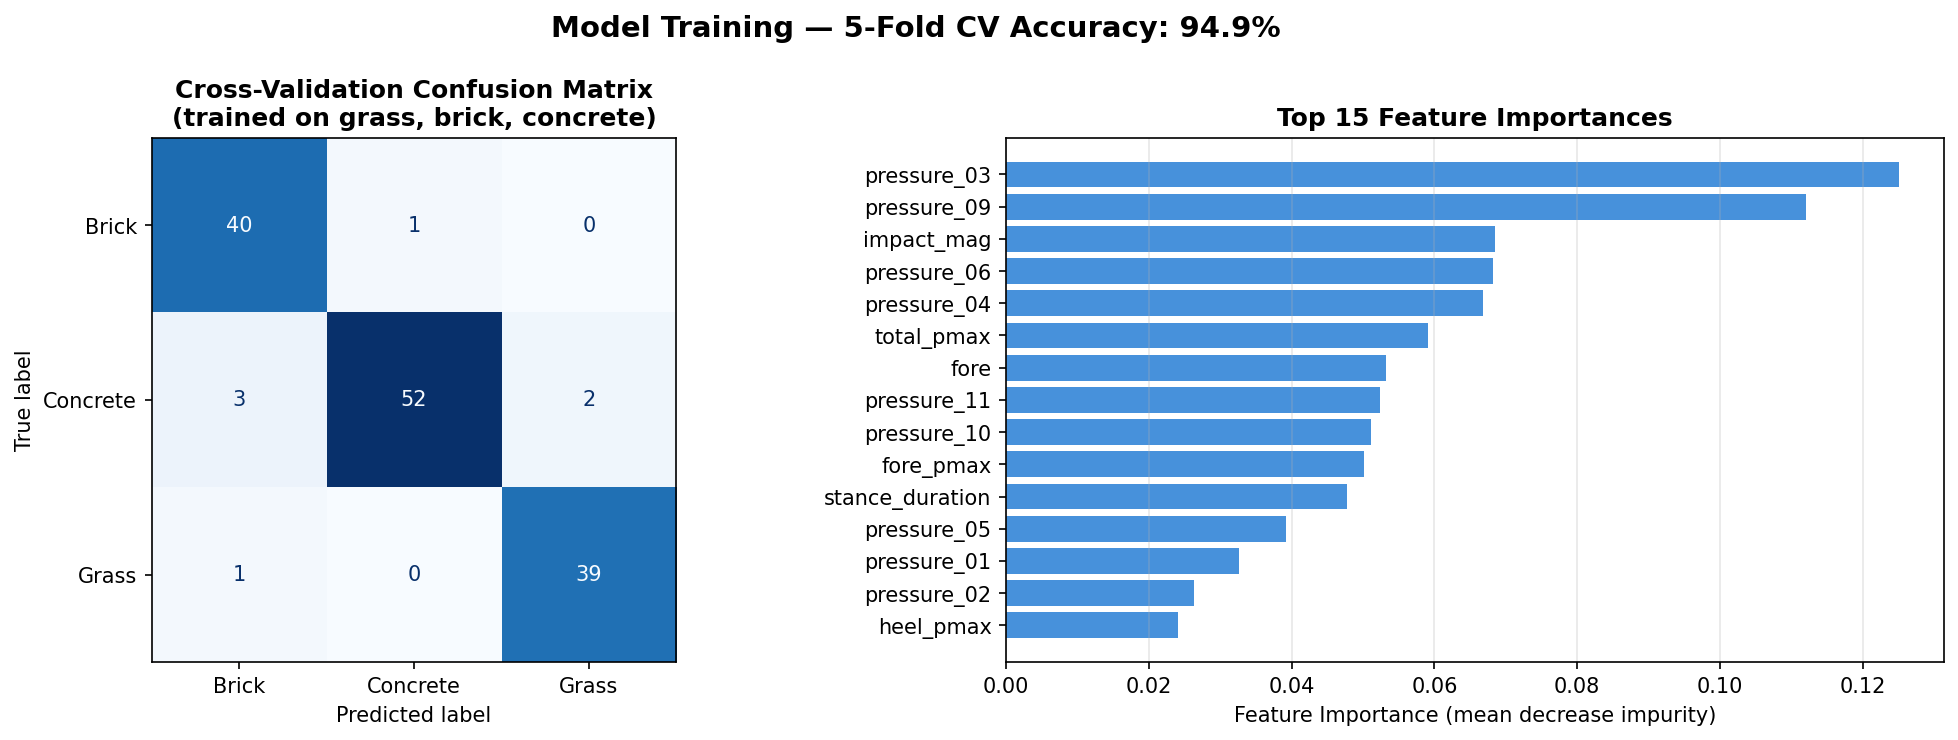

In [ ]:
classes = clf.named_steps['rf'].classes_

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle(f'Model Training — 5-Fold CV Accuracy: {cv_acc*100:.1f}%',
              fontsize=14, fontweight='bold')

cm = confusion_matrix(y_tr, y_cv, labels=classes)
disp = ConfusionMatrixDisplay(cm, display_labels=[c.capitalize() for c in classes])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Cross-Validation Confusion Matrix\n(trained on grass, brick, concrete)',
              fontweight='bold')

importances = clf.named_steps['rf'].feature_importances_
idx = np.argsort(importances)[::-1][:15]
ax2.barh([FEATURE_COLS[i].replace('_mean','') for i in idx[::-1]],
         importances[idx[::-1]], color='#1976D2', alpha=0.8)
ax2.set_xlabel('Feature Importance')
ax2.set_title('Top 15 Feature Importances', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Predict Ground Condition on New Dataset

In [ ]:
print(f'Loading: {NEW_CSV_PATH}')
kraw = pd.read_csv(NEW_CSV_PATH, low_memory=False)
print(f'Rows: {len(kraw)} | Soles: {sorted(kraw["sole_id"].unique())}')

k_frames = []
for sole_id, foot in [(1,'right'), (2,'left')]:
    df = preprocess(kraw[kraw['sole_id'] == sole_id])
    feats = extract_step_features(df, surface_label='?', foot_label=foot)
    if len(feats):
        k_frames.append(feats)
        print(f'  {foot}: {len(feats)} steps detected')

k_df = pd.concat(k_frames, ignore_index=True)
X_k  = k_df[FEATURE_COLS].fillna(0).values

k_df['predicted_surface'] = clf.predict(X_k)
proba = clf.predict_proba(X_k)
for i, c in enumerate(classes):
    k_df[f'prob_{c}'] = proba[:, i]
k_df['max_confidence'] = proba.max(axis=1)

print('\nPrediction distribution (steps per surface per foot):')
print(k_df.groupby(['foot','predicted_surface']).size().unstack(fill_value=0))
print(f'\nMean confidence: {k_df["max_confidence"].mean()*100:.1f}%')
k_df[['foot','step_id','contact_time_sec','predicted_surface','max_confidence']].head(10)

Loading: Kristian_dry_0425.csv
Rows: 51267 | Soles: [1, 2]
  right: 346 steps detected
  left: 347 steps detected

Prediction distribution (steps per surface per foot):
predicted_surface  brick  concrete  grass
foot                                     
left                 251        79     17
right                334        11      1

Mean confidence: 51.2%


## 6. Visualisations
### 6a. Per-Step Prediction Timeline

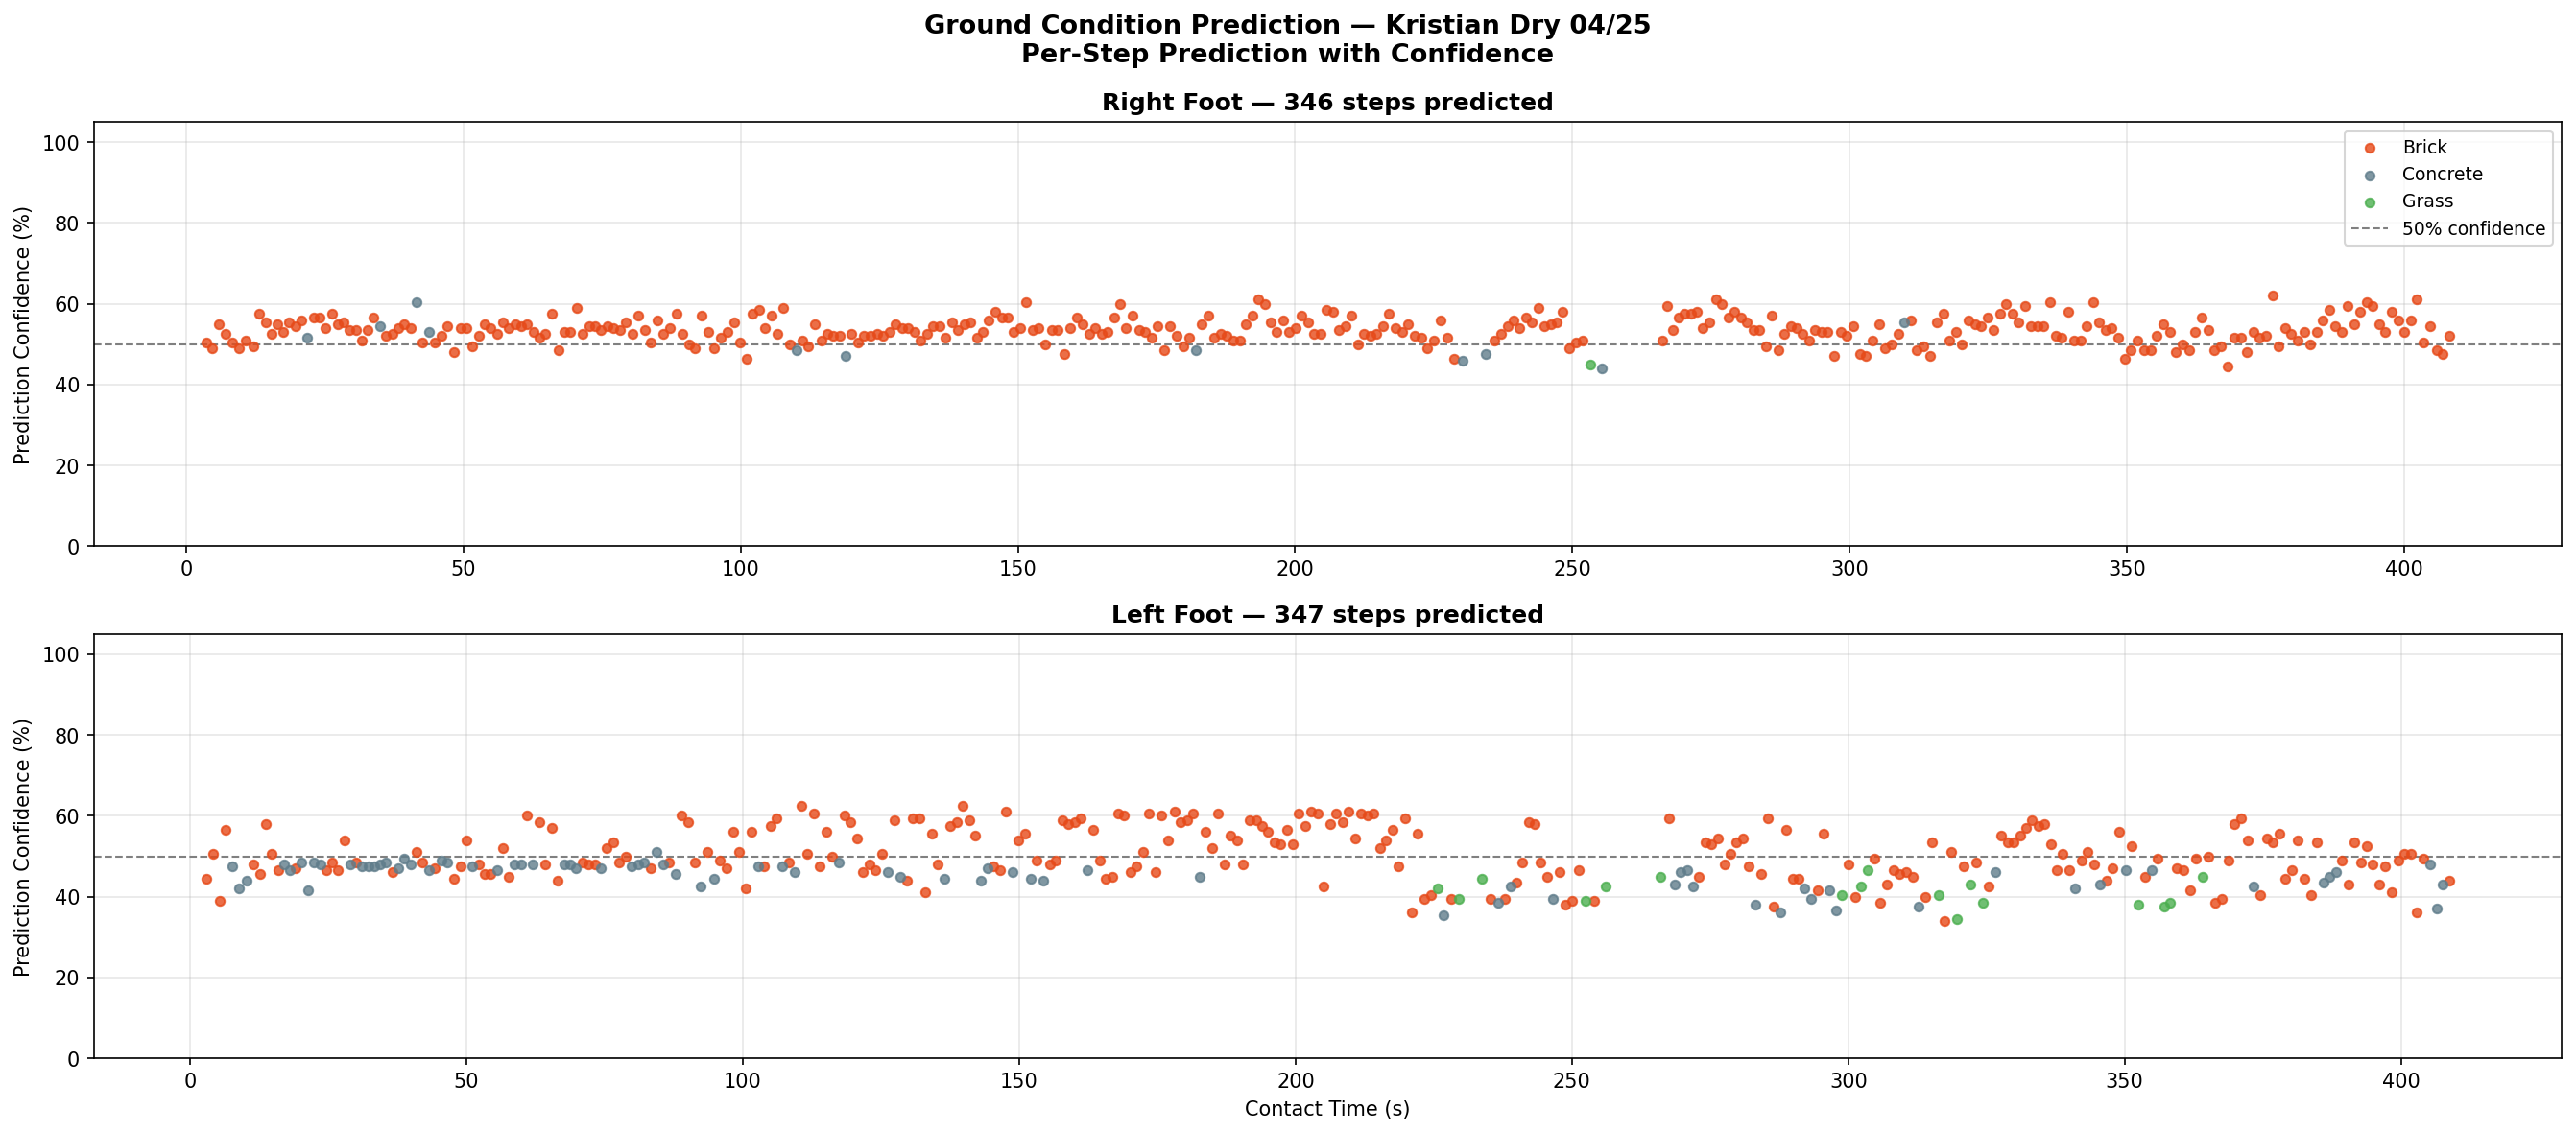

In [ ]:
fig2, axes2 = plt.subplots(2, 1, figsize=(18, 8), sharex=False)
fig2.suptitle(f'Ground Condition Prediction — {NEW_CSV_PATH}\nPer-Step Prediction with Confidence',
              fontsize=13, fontweight='bold')

for ri, foot in enumerate(['right', 'left']):
    ax = axes2[ri]
    sub = k_df[k_df['foot'] == foot].copy()
    for surf in classes:
        s = sub[sub['predicted_surface'] == surf]
        ax.scatter(s['contact_time_sec'], s['max_confidence']*100,
                   color=SURFACE_COLORS[surf], s=20, alpha=0.8,
                   label=surf.capitalize(), zorder=3)
    ax.axhline(50, color='gray', ls='--', lw=1, label='50% confidence')
    ax.set_ylabel('Confidence (%)'); ax.set_ylim(0, 105)
    ax.set_title(f'{foot.capitalize()} Foot — {len(sub)} steps', fontweight='bold')
    ax.grid(alpha=0.3)
    if ri == 0: ax.legend(loc='upper right', fontsize=9)

axes2[1].set_xlabel('Contact Time (s)')
plt.tight_layout(); plt.show()

### 6b. Surface Distribution

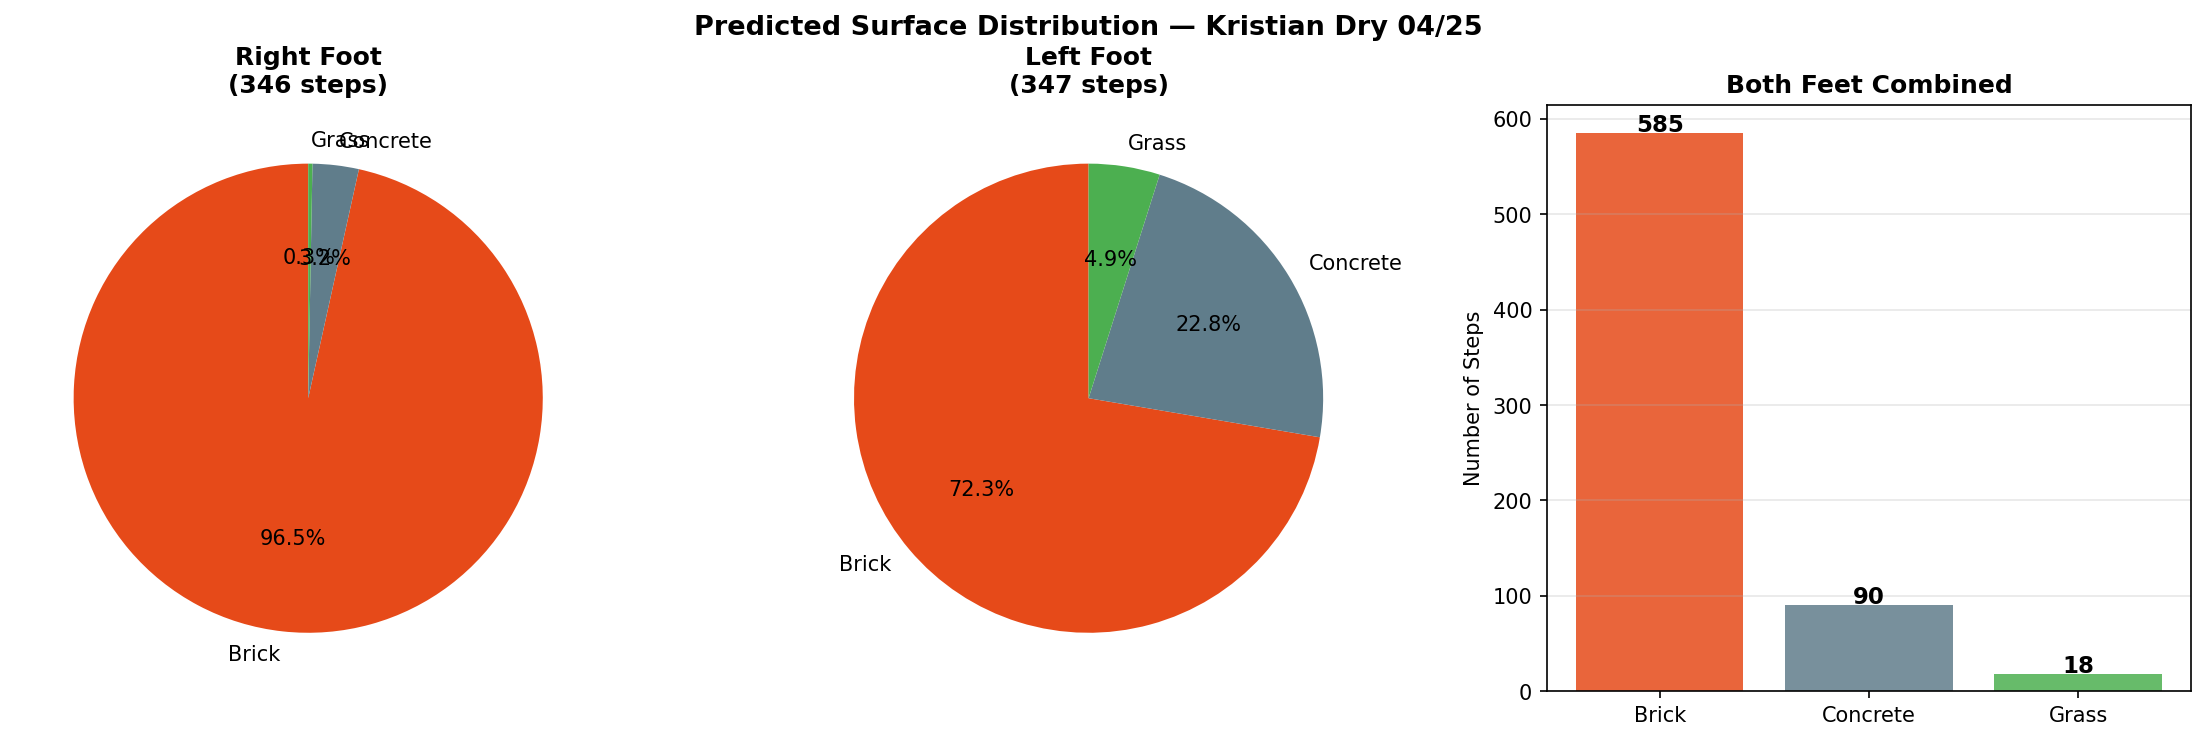

In [ ]:
fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5))
fig3.suptitle(f'Predicted Surface Distribution — {NEW_CSV_PATH}',
              fontsize=13, fontweight='bold')

for i, foot in enumerate(['right', 'left']):
    ax = axes3[i]
    sub = k_df[k_df['foot'] == foot]
    counts = sub['predicted_surface'].value_counts()
    colors = [SURFACE_COLORS[s] for s in counts.index]
    ax.pie(counts, labels=[s.capitalize() for s in counts.index],
           autopct='%1.1f%%', colors=colors, startangle=90)
    ax.set_title(f'{foot.capitalize()} Foot\n({len(sub)} steps)', fontweight='bold')

ax = axes3[2]
both = k_df.groupby('predicted_surface').size().reindex(classes, fill_value=0)
bars = ax.bar([c.capitalize() for c in classes], both.values,
              color=[SURFACE_COLORS[c] for c in classes], alpha=0.85)
for b, v in zip(bars, both.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+2, str(v),
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Steps'); ax.set_title('Both Feet Combined', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### 6c. Confidence Heatmap Over Time

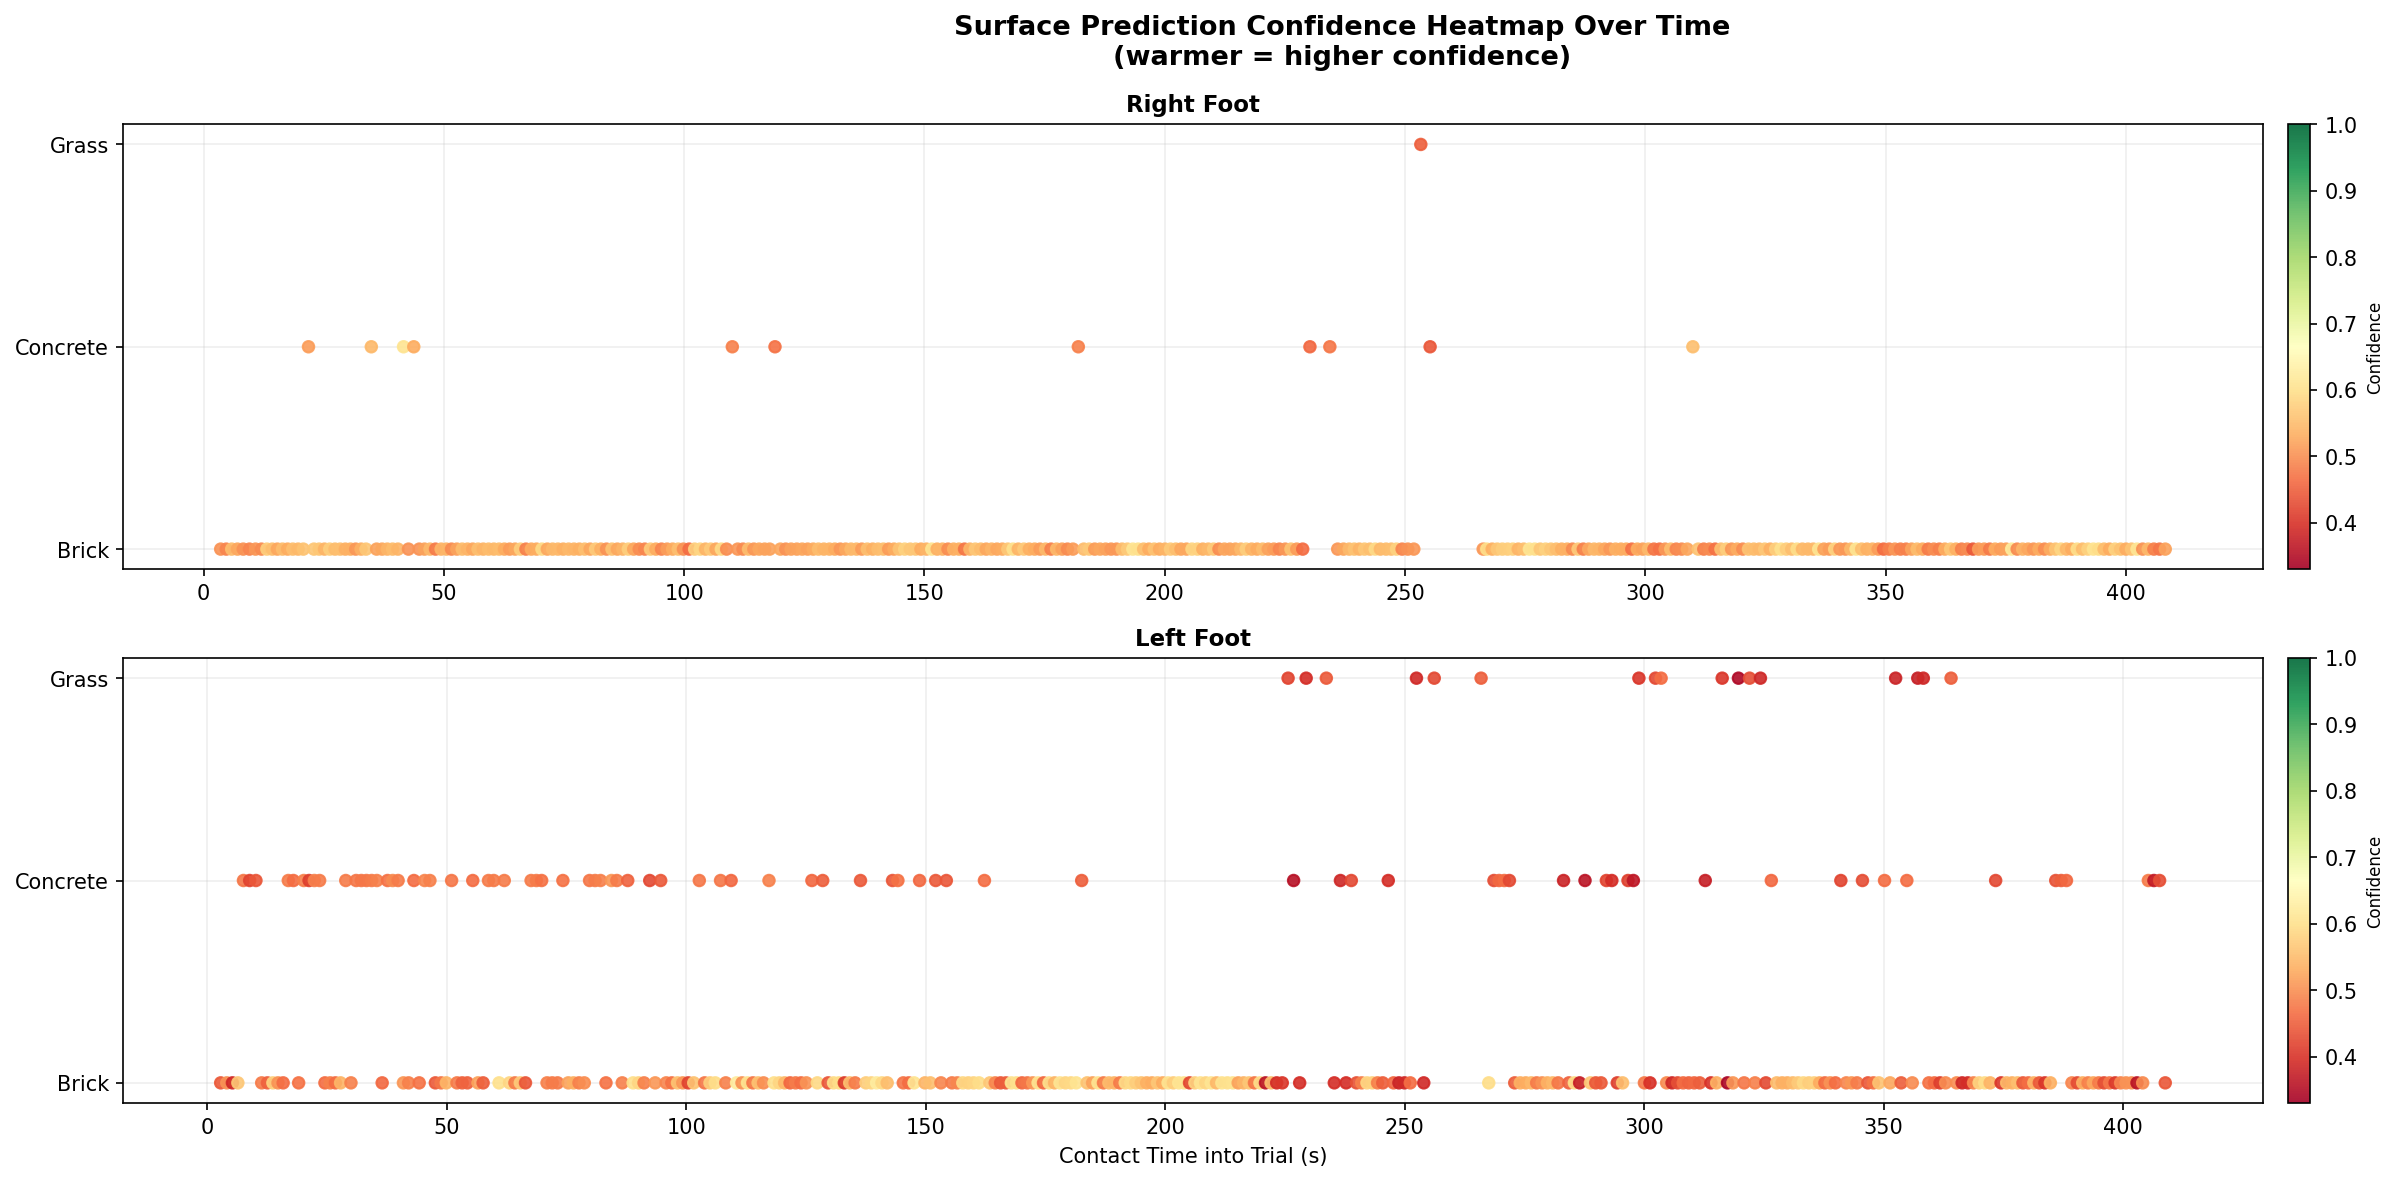

In [ ]:
SURFACE_IDX = {s: i for i, s in enumerate(sorted(classes))}

fig4, axes4 = plt.subplots(2, 1, figsize=(18, 8))
fig4.suptitle('Surface Prediction Confidence Heatmap\n(green=high confidence, red=uncertain)',
              fontsize=13, fontweight='bold')

for ri, foot in enumerate(['right', 'left']):
    ax = axes4[ri]
    sub = k_df[k_df['foot'] == foot].copy()
    sc = ax.scatter(sub['contact_time_sec'],
                    sub['predicted_surface'].map(SURFACE_IDX),
                    c=sub['max_confidence'], cmap='RdYlGn',
                    vmin=0.33, vmax=1.0, s=30, alpha=0.9, zorder=3)
    ax.set_yticks(list(SURFACE_IDX.values()))
    ax.set_yticklabels([s.capitalize() for s in sorted(classes)], fontsize=10)
    ax.set_title(f'{foot.capitalize()} Foot', fontweight='bold', fontsize=11)
    ax.grid(alpha=0.2)
    plt.colorbar(sc, ax=ax, pad=0.01, label='Confidence')

axes4[1].set_xlabel('Contact Time into Trial (s)')
plt.tight_layout(); plt.show()

### 6d. Feature Space — Training vs Predicted

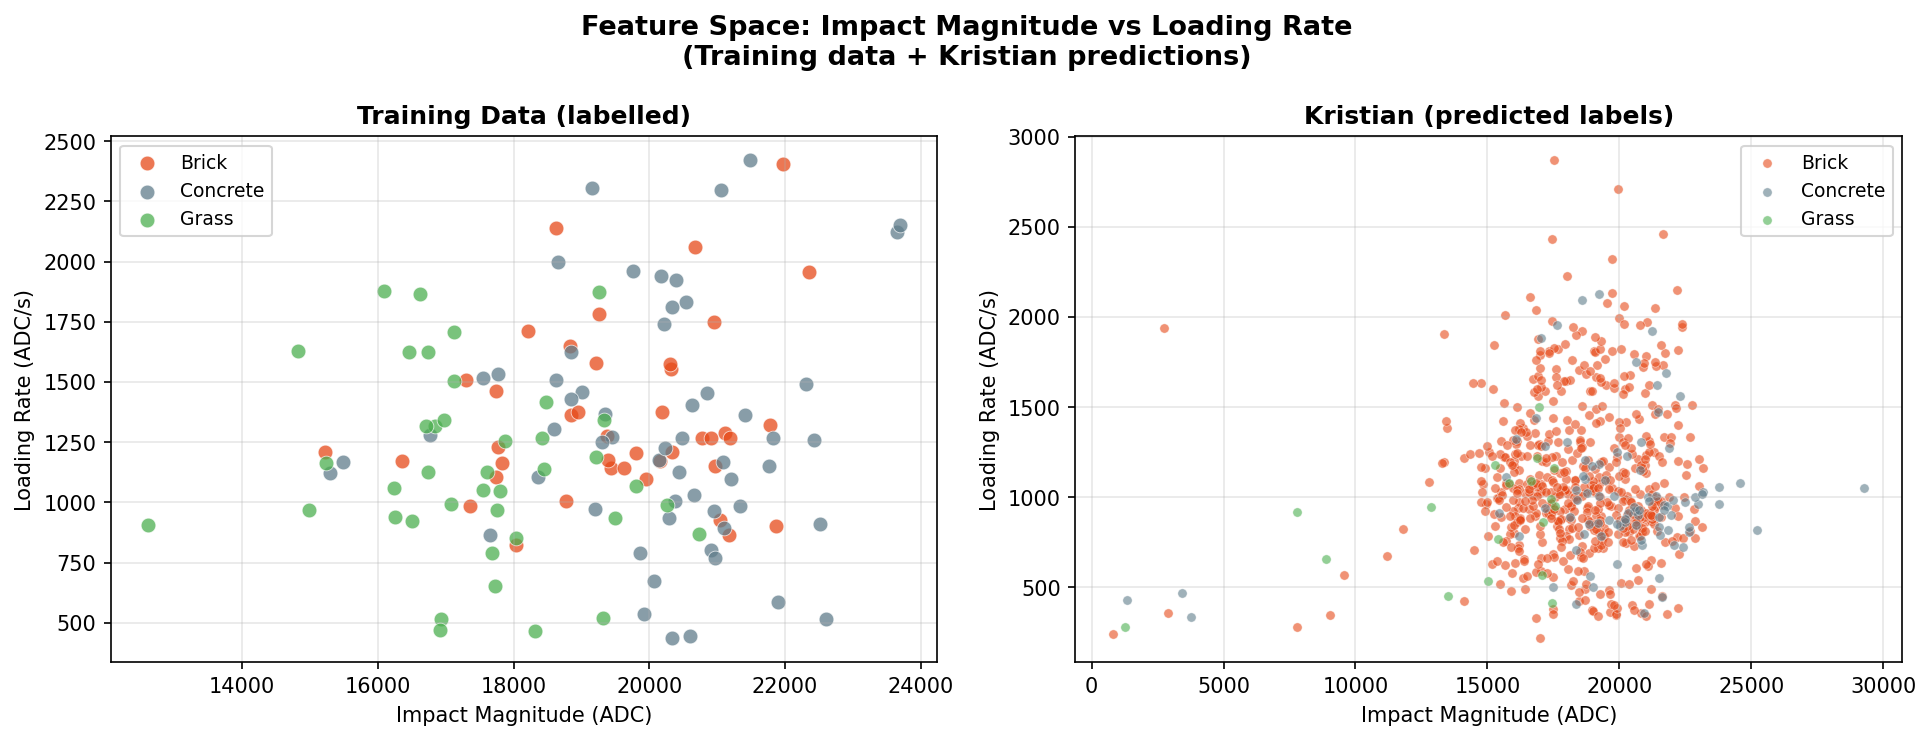

In [ ]:
fig5, axes5 = plt.subplots(1, 2, figsize=(13, 5))
fig5.suptitle('Feature Space: Impact Magnitude vs Loading Rate\n'
              '(Training data coloured by true label, new data by predicted label)',
              fontsize=12, fontweight='bold')

ax = axes5[0]
ax.set_title('Training Data (true labels)', fontweight='bold')
for surf in classes:
    s = train_df[train_df['surface'] == surf]
    ax.scatter(s['impact_mag'], s['loading_rate'], color=SURFACE_COLORS[surf],
               label=surf.capitalize(), s=55, alpha=0.8, edgecolors='w', lw=0.4)
ax.set_xlabel('Impact Magnitude (ADC)'); ax.set_ylabel('Loading Rate (ADC/s)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes5[1]
ax.set_title(f'New Data — {NEW_CSV_PATH} (predicted labels)', fontweight='bold')
for surf in classes:
    s = k_df[k_df['predicted_surface'] == surf]
    ax.scatter(s['impact_mag'], s['loading_rate'], color=SURFACE_COLORS[surf],
               label=surf.capitalize(), s=20, alpha=0.6, edgecolors='w', lw=0.3)
ax.set_xlabel('Impact Magnitude (ADC)'); ax.set_ylabel('Loading Rate (ADC/s)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Export Results

In [ ]:
out_path = NEW_CSV_PATH.replace('.csv','_predictions.csv')
export_cols = ['foot','step_id','contact_time_sec','stance_duration',
               'impact_mag','loading_rate','midstance_diff',
               'heel_pmax','fore_pmax','total_pmax',
               'predicted_surface','max_confidence'] + [f'prob_{c}' for c in classes]
k_df[export_cols].to_csv(out_path, index=False)
print(f'Saved {len(k_df)} rows -> {out_path}')
print(k_df[export_cols].head(8).to_string(index=False))

Saved 693 rows -> Kristian_dry_0425_predictions.csv
